In [86]:
from langgraph.graph import StateGraph ,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict,Annotated,Literal
from dotenv import load_dotenv
from pydantic import BaseModel,Field
import operator

In [87]:
load_dotenv()
model=ChatOpenAI(model='gpt-4o-mini')

In [88]:
class SentimentSchema(BaseModel):

  sentiment:Literal['Positive','Negative'] =Field(description="sentiment of the review")

In [89]:
class DignosisSchema(BaseModel):
  issue_type:Literal['UX','performence','Bug','Support','Other']=Field(description='The categories of issue menstioned in the review')
  ton:Literal['angry','frustrated','disppointed']=Field(description='The emotional tone expressed by the user')
  urgency:Literal['low','medium','high']=Field(description='How urgent or critical the issue appears to be')

In [90]:
structured_model=model.with_structured_output(SentimentSchema)
structured_model2=model.with_structured_output(DignosisSchema)

In [91]:
prompt='what is the sentiment of the following review -the software is too good'
output1=structured_model.invoke(prompt)
output2=structured_model2.invoke(prompt)

print(output1)
print(output2)

sentiment='Positive'
issue_type='Other' ton='frustrated' urgency='low'


In [92]:
class ReviewState(TypedDict):

  review:str
  sentiment:Literal['Positive','Negative']
  dignosis:dict
  response:str
  

In [93]:
def find_sentiments(state:ReviewState):
  prompt=f"For the following review find out the sentiment \n {state['review']}"

  sentiment=structured_model.invoke(prompt).sentiment

  return {'sentiment':sentiment}

def positive_response(state:ReviewState):
  prompt=f"""Write a warm thankYou message in response to this review: \n\n {state['review']} \n Also, kindly ask the user to leave feedback on our website."""

  response=model.invoke(prompt)

  return {'response':response}

def run_dignosis(state:ReviewState):
  prompt=f"""Dygnose this negative review:\n\n{state['review']}\n ""return issue_type tone , and urgency.
"""
  response=structured_model2.invoke(prompt)
  return {'dignosis':response.model_dump()}

def negative_response(state:ReviewState):
  dignosis=state['dignosis']
  prompt=f""" You are  a support assistance.
  The user had a' {dignosis['issue_type']}' issue , sounded '{dignosis['ton']}' , and marked urgency as '{dignosis['urgency']}'.
  Write an empathetic helpful resolution message.
"""
  response=model.invoke(prompt).content

  return {'response':response}

def check_sentiment(state:ReviewState) ->Literal['positive_response','run_dignosis']:

  if state['sentiment'] == 'Positive':
    return 'positive_response'
  else:
    return 'run_dignosis'
  


In [94]:
graph=StateGraph(ReviewState)

graph.add_node('find_sentiments',find_sentiments)
graph.add_node('positive_response',positive_response)
graph.add_node('run_dignosis',run_dignosis)
graph.add_node('negative_response',negative_response)

graph.add_edge(START,'find_sentiments')
graph.add_conditional_edges('find_sentiments',check_sentiment)
graph.add_edge('positive_response',END)
graph.add_edge('run_dignosis','negative_response')
graph.add_edge('negative_response',END)

workflow=graph.compile()


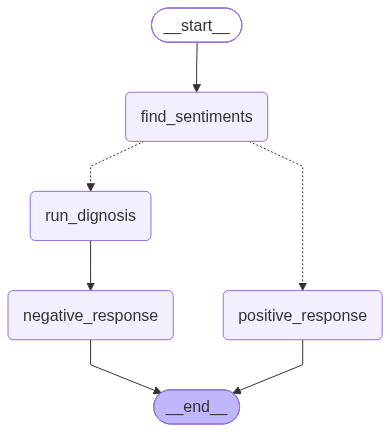

In [95]:
workflow

In [102]:
initial_state={
  'review':'I am very disappointed with this product. It stopped working within a week of purchase. Customer support has been unhelpful and keeps delaying a solution. This has been a frustrating experience and I feel like I wasted my money.'
}

In [103]:
workflow.invoke(initial_state)

{'review': 'I am very disappointed with this product. It stopped working within a week of purchase. Customer support has been unhelpful and keeps delaying a solution. This has been a frustrating experience and I feel like I wasted my money.',
 'sentiment': 'Negative',
 'dignosis': {'issue_type': 'Bug', 'ton': 'disppointed', 'urgency': 'high'},
 'response': "Subject: We’re Here to Help!\n\nDear [User's Name],\n\nThank you for reaching out and bringing this issue to our attention. I genuinely understand how frustrating it can be to encounter a bug, especially when it disrupts your experience. Please know that we take your concerns seriously and are committed to helping you resolve this as quickly as possible.\n\nTo assist you better, could you please provide a bit more detail about the bug you're experiencing? Any specific error messages, steps to reproduce the issue, or screenshots would be incredibly helpful for our team to pinpoint the problem.\n\nIn the meantime, I appreciate your pa